<a href="https://colab.research.google.com/github/pmfarhana25/ict_assignments/blob/main/case_study1_farahana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
df = pd.read_csv('/content/athlete_events - medal.csv')
df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992.0,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012.0,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920.0,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900.0,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988.0,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246859,123601,Nataliya Andreyevna Ustinova,F,19.0,165.0,58.0,Soviet Union,URS,1964 Summer,1964.0,Summer,Tokyo,Swimming,Swimming Women's 4 x 100 metres Medley Relay,Bronze
246860,123601,Nataliya Andreyevna Ustinova,F,23.0,165.0,58.0,Soviet Union,URS,1968 Summer,1968.0,Summer,Mexico City,Swimming,Swimming Women's 100 metres Freestyle,NaN
246861,123601,Nataliya Andreyevna Ustinova,F,23.0,165.0,58.0,Soviet Union,URS,1968 Summer,1968.0,Summer,Mexico City,Swimming,Swimming Women's 4 x 100 metres Freestyle Relay,NaN
246862,123602,Tetiana Illivna Ustiuzhanina,F,27.0,185.0,78.0,Unified Team,EUN,1992 Summer,1992.0,Summer,Barcelona,Rowing,Rowing Women's Quadruple Sculls,Bronze


PART 1 : DATA UNDERSTANDING

Q1.LOAD THE DATASET

In [42]:
df.head() #first 5 rows

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992.0,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012.0,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920.0,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900.0,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988.0,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [43]:
df.shape #number of column and row

(246864, 15)

In [64]:
display(df.columns)

Index(['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games',
       'Year', 'Season', 'City', 'Sport', 'Event', 'Medal'],
      dtype='object')

Q2.CHECK DATA TYPES

In [45]:
df.dtypes

,0
ID,int64
Name,object
Sex,object
Age,float64
Height,float64
Weight,float64
Team,object
NOC,object
Games,object
Year,float64


In [46]:
num = df.select_dtypes(include=['int64', 'float64']).columns
print("numerical columns:")
print(num)


numerical columns:
Index(['ID', 'Age', 'Height', 'Weight', 'Year'], dtype='object')


In [47]:
cat = df.select_dtypes(include=['object']).columns
print("categorical columns:")
print(cat)

categorical columns:
Index(['Name', 'Sex', 'Team', 'NOC', 'Games', 'Season', 'City', 'Sport',
       'Event', 'Medal'],
      dtype='object')


Q3.MISSING VALUES

In [48]:
df.isnull().sum()

,0
ID,0
Name,0
Sex,0
Age,8667
Height,54813
Weight,57347
Team,0
NOC,0
Games,0
Year,1


In [49]:
df['Medal'].unique()

array([nan, 'Gold', 'Bronze', 'Silver'], dtype=object)

PART2 -MEDAL FILTERING

Q4.create a new Dataframe containing only medal winners

In [50]:
medal_winners_df = df.dropna(subset=['Medal'])


In [51]:
display(medal_winners_df.head())

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900.0,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
37,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920.0,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze
38,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920.0,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze
40,16,Juhamatti Tapio Aaltonen,M,28.0,184.0,85.0,Finland,FIN,2014 Winter,2014.0,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze
41,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948.0,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze


PART3 - COUNTRY ANALYSIS

Q5.TOTAL MEDAL COUNT

In [54]:
top_10_countries = (
  medal_winners_df.groupby('NOC')
  .size()
  .sort_values(ascending=False)
  .head(10)
)

print(top_10_countries)

NOC
USA    5161
URS    2271
GBR    1904
GER    1883
FRA    1714
ITA    1530
SWE    1433
CAN    1239
AUS    1219
HUN    1048
dtype: int64


Q6. VISUALIZE TOP 10 COUNTRIES

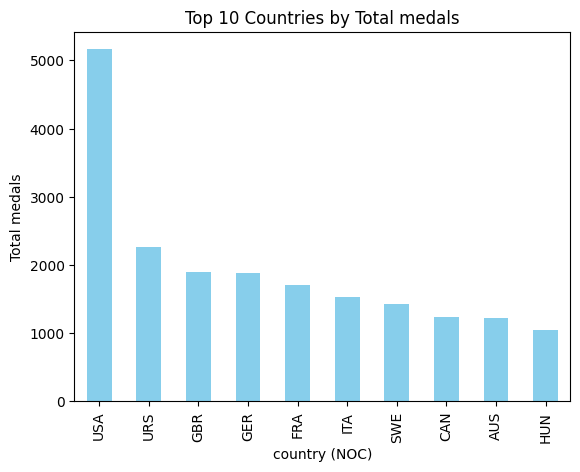

In [62]:
top_10_countries.plot(kind='bar',color='skyblue')
plt.title('Top 10 Countries by Total medals')
plt.xlabel('country (NOC)')
plt.ylabel('Total medals')
plt.show()

Q7. GOLD MEDAL ANALYSIS

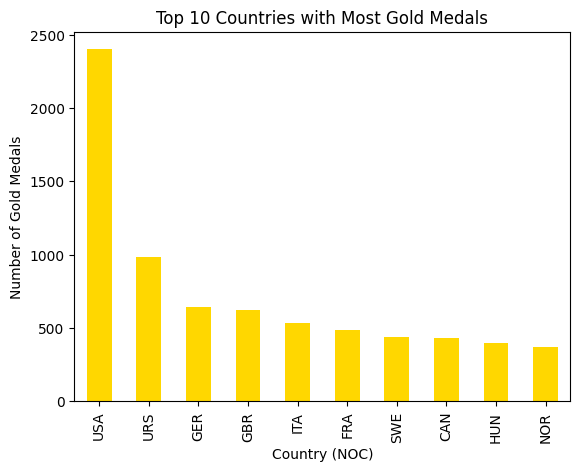

In [63]:
gold = medal_winners_df[medal_winners_df['Medal'] == 'Gold']
top_gold = gold['NOC'].value_counts().head(10)
top_gold.plot(kind='bar',color='gold')
plt.title('Top 10 Countries with Most Gold Medals')
plt.xlabel('Country (NOC)')
plt.ylabel('Number of Gold Medals')
plt.show()

part4 - gender analysis


In [65]:
gender_medal_counts = medal_winners_df['Sex'].value_counts()
display(gender_medal_counts)

,count
Sex,
M,25972
F,9984


/tmp/ipykernel_282/1269135987.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_medal_counts.index, y=gender_medal_counts.values, palette='viridis')


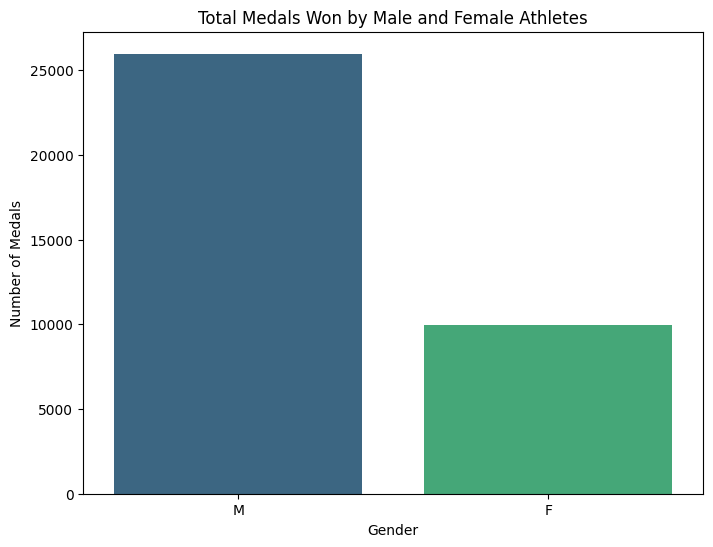

In [66]:
plt.figure(figsize=(8, 6))
sns.barplot(x=gender_medal_counts.index, y=gender_medal_counts.values, palette='viridis')
plt.title('Total Medals Won by Male and Female Athletes')
plt.xlabel('Gender')
plt.ylabel('Number of Medals')
plt.show()

Q9

In [67]:
medals_by_year_sex = medal_winners_df.groupby(['Year', 'Sex']).size().reset_index(name='Medal_Count')
display(medals_by_year_sex.head())

,Year,Sex,Medal_Count
0,1896.0,M,129
1,1900.0,F,12
2,1900.0,M,543
3,1904.0,F,9
4,1904.0,M,422


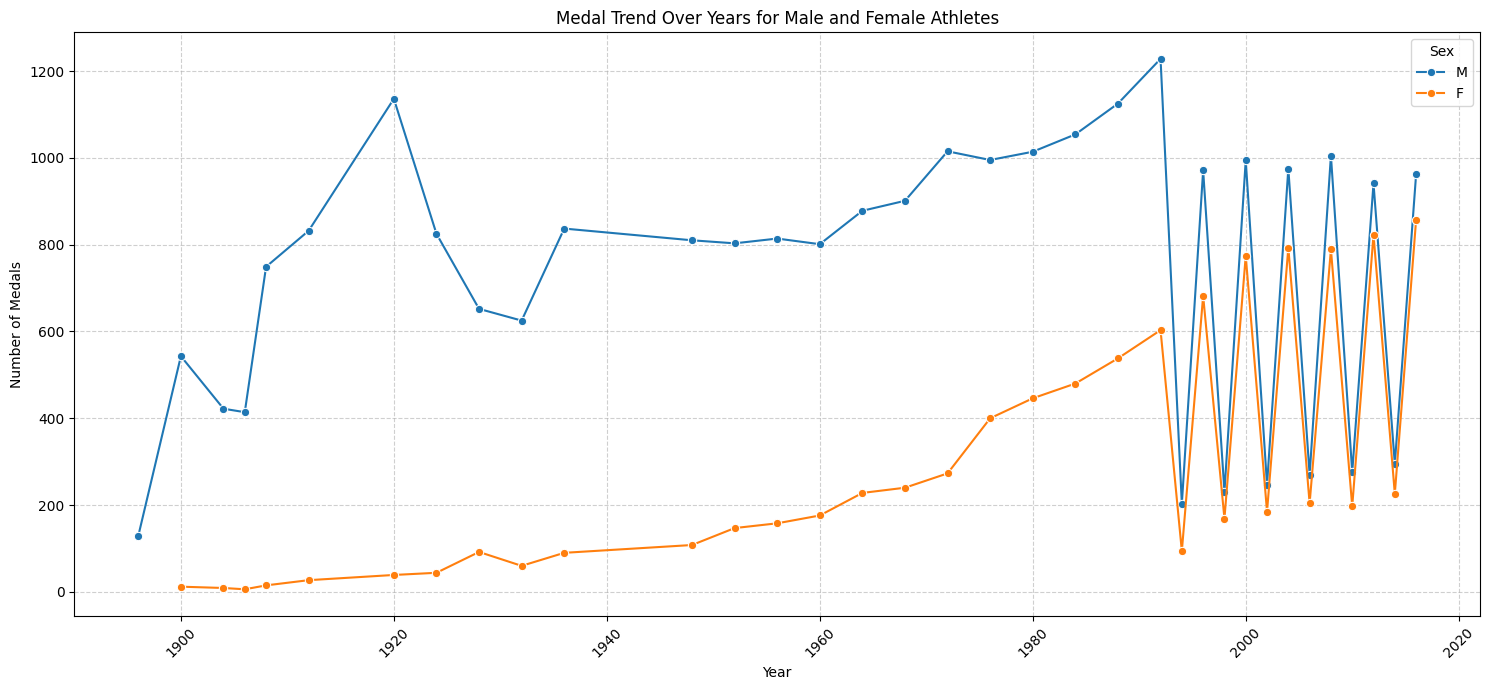

In [68]:
plt.figure(figsize=(15, 7))
sns.lineplot(data=medals_by_year_sex, x='Year', y='Medal_Count', hue='Sex', marker='o')
plt.title('Medal Trend Over Years for Male and Female Athletes')
plt.xlabel('Year')
plt.ylabel('Number of Medals')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

PART 5

Q10

In [69]:
top_10_sports = medal_winners_df['Sport'].value_counts().head(10)
display(top_10_sports)

,count
Sport,
Athletics,3654
Swimming,2717
Rowing,2683
Gymnastics,2049
Fencing,1599
Football,1439
Ice Hockey,1414
Hockey,1366
Wrestling,1178


/tmp/ipykernel_282/934815842.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_sports.index, y=top_10_sports.values, palette='crest')


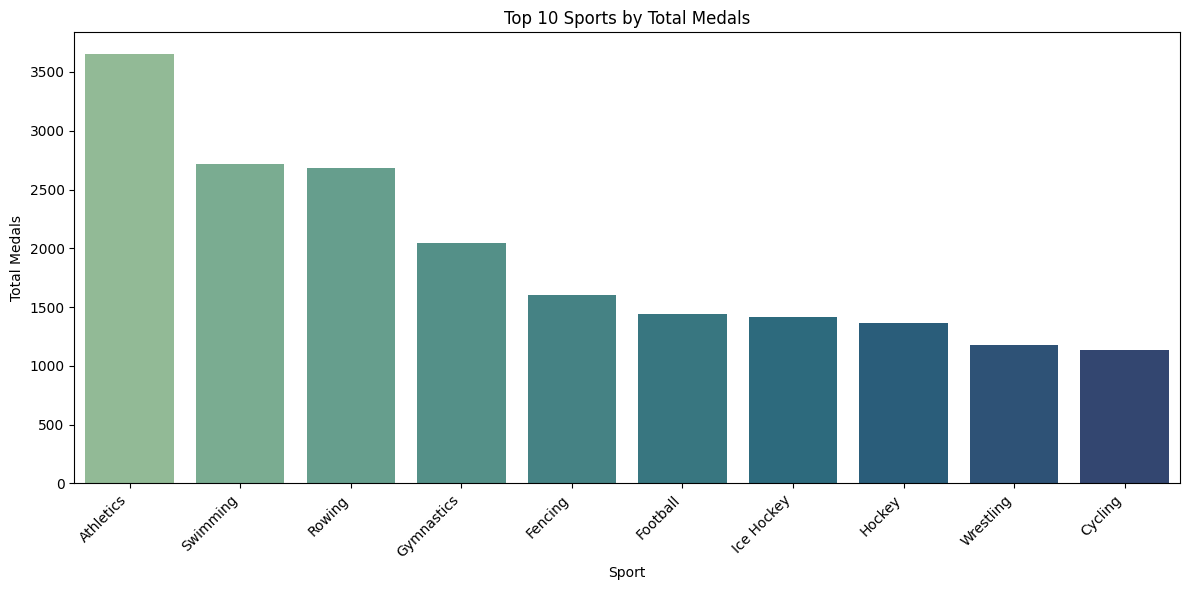

In [70]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_sports.index, y=top_10_sports.values, palette='crest')
plt.title('Top 10 Sports by Total Medals')
plt.xlabel('Sport')
plt.ylabel('Total Medals')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Q11

In [72]:
gold_medals_by_sport = medal_winners_df[medal_winners_df['Medal'] == 'Gold']['Sport'].value_counts()
highest_gold_sport = gold_medals_by_sport.idxmax()
highest_gold_count = gold_medals_by_sport.max()

print(f"The sport with the highest number of Gold medals is: {highest_gold_sport} with {highest_gold_count} Gold medals.")

The sport with the highest number of Gold medals is: Athletics with 1230 Gold medals.


PART 6


Q12.


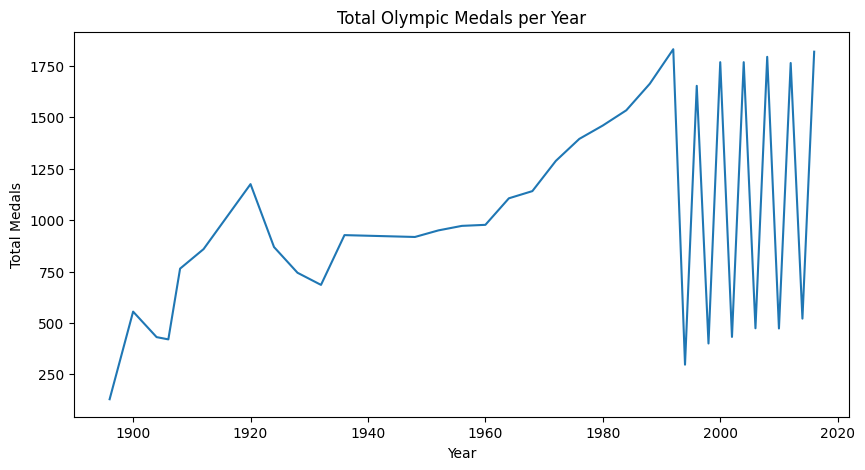

In [73]:
medals = df[df["Medal"].notna()]
medals_per_year = medals.groupby("Year").size()
plt.figure(figsize=(10,5))
plt.plot(medals_per_year.index, medals_per_year.values)
plt.xlabel("Year")
plt.ylabel("Total Medals")
plt.title("Total Olympic Medals per Year")
plt.show()

Q13.

In [74]:

medal_df = df[df["Medal"].notna()]
medals_per_year = medal_df.groupby("Year").size()

max_year = medals_per_year.idxmax()
max_medals = medals_per_year.max()

print("Year with highest medals:", max_year)
print("Total medals in that year:", max_medals)

Year with highest medals: 1992.0
Total medals in that year: 1831


 PART 7


Q14.


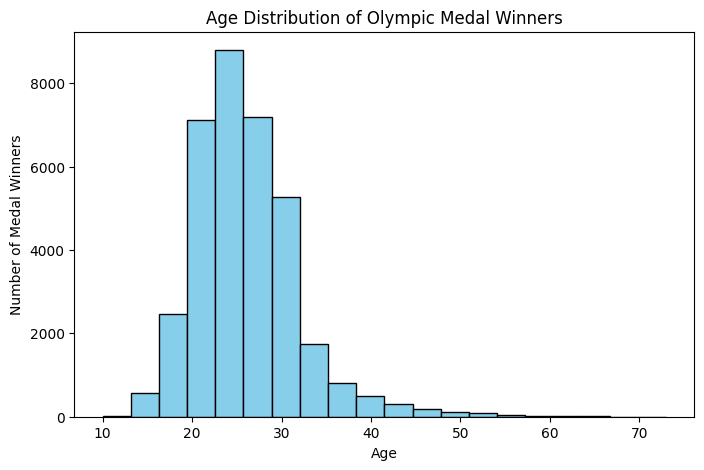

Most common winning age range: (20, 25]


In [75]:

medal_winners = df[df["Medal"].notna()]
ages = medal_winners["Age"].dropna()
plt.figure(figsize=(8,5))
plt.hist(ages, bins=20, color='skyblue', edgecolor='black')
plt.xlabel("Age")
plt.ylabel("Number of Medal Winners")
plt.title("Age Distribution of Olympic Medal Winners")
plt.show()
age_range = pd.cut(ages, bins=range(10, 60, 5))
most_common_range = age_range.value_counts().idxmax()

print("Most common winning age range:", most_common_range)

Q15

In [77]:

medal_winners = df[df["Medal"].notna()]
medal_winners = medal_winners.dropna(subset=["Age"])
avg_age = medal_winners.groupby("Medal")["Age"].mean()
avg_age

,Age
Medal,
Bronze,25.902074
Gold,25.906690
Silver,26.027022


PART 8

Q16


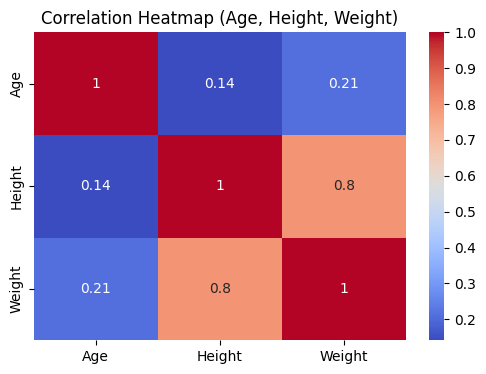

             Age    Height    Weight
Age     1.000000  0.141762  0.211581
Height  0.141762  1.000000  0.795940
Weight  0.211581  0.795940  1.000000


In [78]:

data = df[["Age", "Height", "Weight"]]
data = data.dropna()
corr = data.corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Age, Height, Weight)")
plt.show()

print(corr)

PART 9


Q17

Total Medals: 195
Gold Medals: 136
Best Sport: Hockey


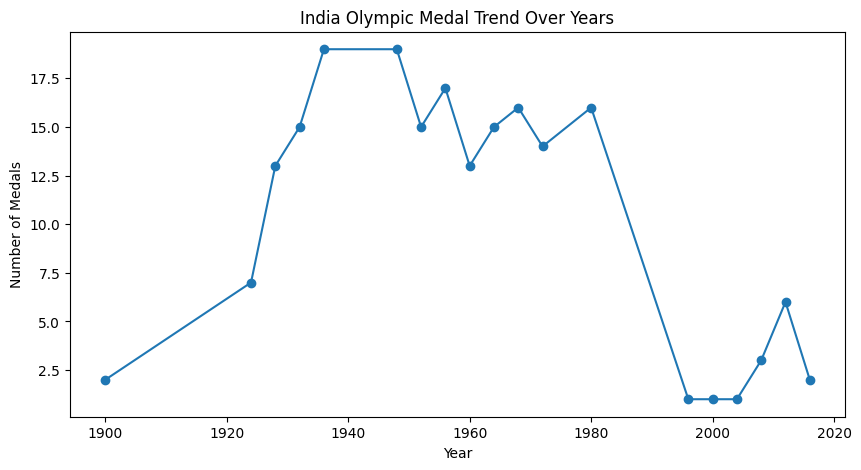

In [79]:
india = df[df["NOC"] == "IND"]
india_medals = india[india["Medal"].notna()]
total_medals = len(india_medals)
gold_medals = len(india_medals[india_medals["Medal"] == "Gold"])
best_sport = india_medals["Sport"].value_counts().idxmax()

print("Total Medals:", total_medals)
print("Gold Medals:", gold_medals)
print("Best Sport:", best_sport)
medal_trend = india_medals.groupby("Year").size()

plt.figure(figsize=(10,5))
plt.plot(medal_trend.index, medal_trend.values, marker='o')
plt.xlabel("Year")
plt.ylabel("Number of Medals")
plt.title("India Olympic Medal Trend Over Years")
plt.show()

Q18.

Dominant Country: USA
Total Medals: 1006


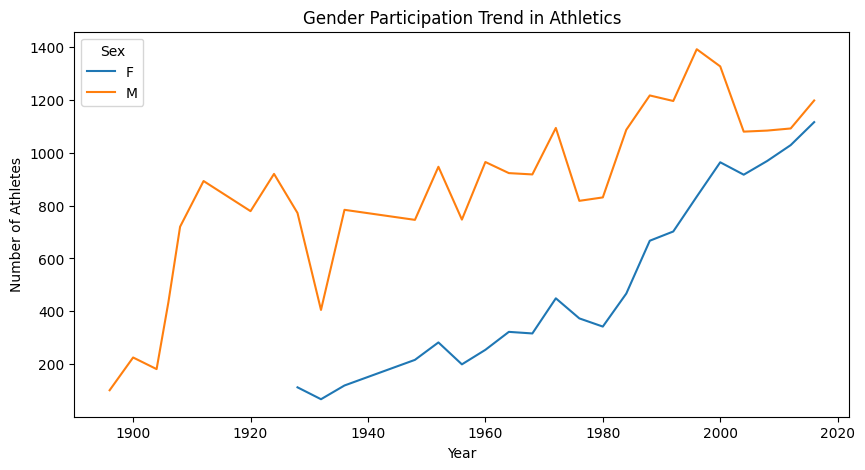

Average Age of Winners: 25.02009911894273


In [80]:
sport = "Athletics"
sport_df = df[df["Sport"] == sport]
medal_df = sport_df[sport_df["Medal"].notna()]
top_country = medal_df["NOC"].value_counts().idxmax()
top_country_medals = medal_df["NOC"].value_counts().max()

print("Dominant Country:", top_country)
print("Total Medals:", top_country_medals)
gender_trend = sport_df.groupby(["Year","Sex"]).size().unstack()

gender_trend.plot(figsize=(10,5))
plt.title("Gender Participation Trend in Athletics")
plt.xlabel("Year")
plt.ylabel("Number of Athletes")
plt.show()

avg_age = medal_df["Age"].mean()
print("Average Age of Winners:", avg_age)

BONUS (Optional)

Q19.

In [82]:
gold_winners = df[df["Medal"] == "Gold"]
gold_winners = gold_winners.dropna(subset=["Age"])
youngest_gold = gold_winners.sort_values(by="Age").head(5)
youngest_gold[["Name","Sex","Age","Year","Sport","Event"]]

,Name,Sex,Age,Year,Sport,Event
78544,Marjorie Gestring (-Redlick),F,13.0,1936.0,Diving,Diving Women's Springboard
73581,Fu Mingxia,F,13.0,1992.0,Diving,Diving Women's Platform
52010,Donna Elizabeth de Varona (-Pinto),F,13.0,1960.0,Swimming,Swimming Women's 4 x 100 metres Freestyle Relay
200704,Aileen Muriel Riggin (-Soule),F,13.0,1920.0,Diving,Diving Women's Springboard
119277,Kim Yun-Mi,F,13.0,1994.0,Short Track Speed Skating,"Short Track Speed Skating Women's 3,000 metres..."


Q20.


In [84]:
medals = df[df["Medal"].notna()]
total_medals = medals["NOC"].value_counts()
top5_countries = total_medals.head(5).index
gold_medals = medals[medals["Medal"]=="Gold"]["NOC"].value_counts()
gold_ratio = (gold_medals[top5_countries] / total_medals[top5_countries]).round(2)
result = pd.DataFrame({
    "Total Medals": total_medals[top5_countries],
    "Gold Medals": gold_medals[top5_countries],
    "Gold/Total Ratio": gold_ratio
})
result

,Total Medals,Gold Medals,Gold/Total Ratio
NOC,,,
USA,5161,2400,0.47
URS,2271,985,0.43
GBR,1904,627,0.33
GER,1883,643,0.34
FRA,1714,488,0.28
